In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [38]:
class QLearn_Agent():
    def __init__(self,env,alpha=0.1,gamma=0.99):
        self.env=env
        self.alpha=alpha
        self.gamma=gamma
        self.Q_table=self.initialize_q_table(self.env.observation_space.n, self.env.action_space.n)
        self.gridsize=int(np.sqrt(self.env.observation_space.n))

    def initialize_q_table(self,states,actions):
        return np.zeros((states,actions))
    
    def choose_action(self,state,epsilon):
        random=np.random.rand()
        if(random<epsilon):
            return self.env.action_space.sample()
        else:
            return np.argmax(self.Q_table[state])
    
    def train(self,episodes=1):
        episode_rewards=[]
        for episode in range(episodes):
            state=self.env.reset()[0]
            done=False

            cumulative_reward=episode_rewards[-1] if len(episode_rewards)>0 else 0

            epsilon=0.99
            while not done:
                action=self.choose_action(state,epsilon)
                next_state,reward,done,_,_=self.env.step(action)
                self.Q_table[state][action]+=self.alpha*(reward+self.gamma*(self.Q_table[next_state].max())-self.Q_table[state][action])
                state=next_state
                cumulative_reward+=reward
                epsilon=max(0.01,epsilon*0.99)
            episode_rewards.append(cumulative_reward)
        plt.figure(figsize=(20,5))
        plt.title("Cumulative Reward Over Episodes")
        plt.plot(episode_rewards)

In [39]:
env=gym.make("FrozenLake-v1")

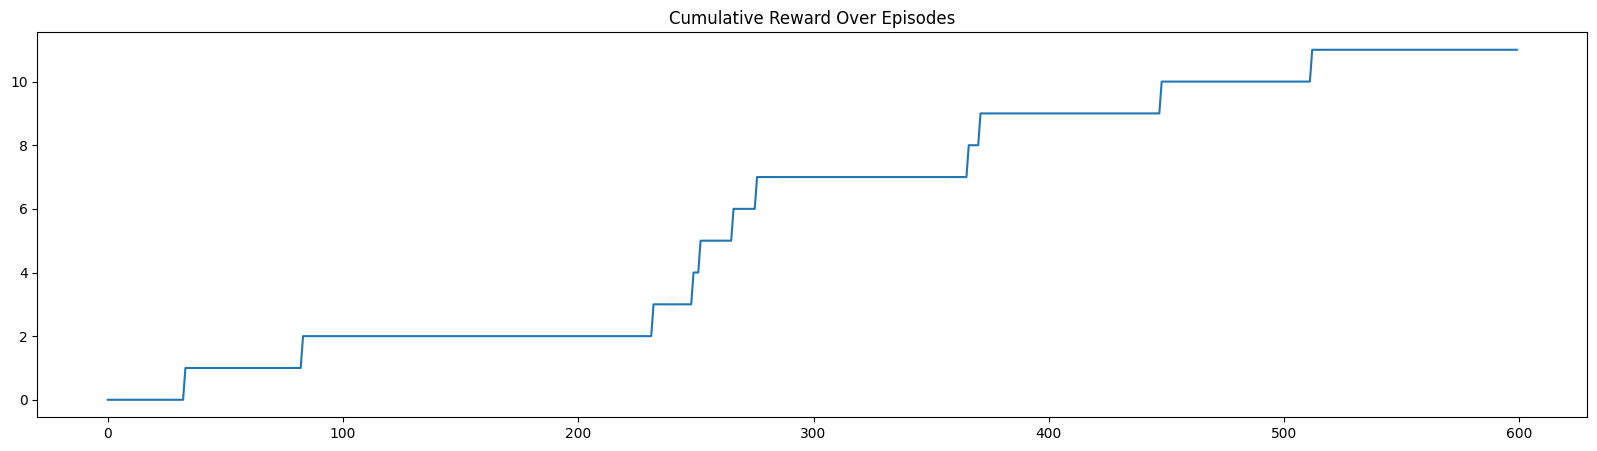

In [40]:
agent=QLearn_Agent(env)
agent.train(600)